### Imports and Constants

In [39]:
import sys
sys.path.append('../')

from src.run_app import *
from src.prepare_gam import *
from src.utils import *
from src.rset_opt import *
from FasterRisk.src.fasterrisk import fasterrisk
from gam_rs_utils.binarize_dataset import binarize_dataset
from gam_rs_utils.utils import *
from method_scripts.results_class import *
from method_scripts.base_method import *
from gam_rs_utils.multi_plotter import MultiPlotter

from time import time
import pickle as pkl

In [40]:
methods = [
    "uniform__ellipsoid_sampling",
    # "uniform_surface_ellipsoid_sampling",
    "poisson__ellipsoid_sampling",
    # "poisson_euclidean_ellipsoid_sampling",
    "permutation__ellipsoid_sampling",
    # "permutation_poisson_ellipsoid_sampling",
    "blocking",
    # "quadratic",
    # "swapping_1",
    # "swapping_2",
    "swapping_3",
    # "swapping_4",
    # "swapping_5",
    "hybrid",
]
methods = [
    "poisson_r_min_0.01_ellipsoid_sampling",
    "poisson_r_min_0.1_ellipsoid_sampling",
    "poisson_r_min_0.2_ellipsoid_sampling",
    "poisson_r_min_0.3_ellipsoid_sampling",
    "poisson_r_min_0.4_ellipsoid_sampling",
]
method_to_name = {
    "uniform__ellipsoid_sampling": "Uniform Sampling",
    "poisson__ellipsoid_sampling": "Poisson Sampling",
    "permutation__ellipsoid_sampling": "Permutation Sampling",
    "blocking": "Blocking",
    "hybrid": "Hybrid",
    "swapping_3": "Swapping",
    "poisson_r_min_0.01_ellipsoid_sampling": "Poisson Sampling (r_min=0.01)",
    "poisson_r_min_0.1_ellipsoid_sampling": "Poisson Sampling (r_min=0.1)",
    "poisson_r_min_0.2_ellipsoid_sampling": "Poisson Sampling (r_min=0.2)",
    "poisson_r_min_0.3_ellipsoid_sampling": "Poisson Sampling (r_min=0.3)",
    "poisson_r_min_0.4_ellipsoid_sampling": "Poisson Sampling (r_min=0.4)",
}
dataset_names = ["bank", "compas", "diabetes", "spambase", "mimic2"]

In [41]:
def get_all_datasets_results(methods, dataset_names):
    all_datasets_results = {}
    for dname in dataset_names:
        all_columns = set()
        method_dfs = {}
        for method in methods:
            data = load_results(f"../analysis/results/methods/{method}.pkl")
            df = pd.DataFrame(data)
            df = df[df["dataset"] == dname]
            method_dfs[method] = df
            all_columns.update(df.columns)
        all_columns = list(all_columns)

        dfs = []
        for method, df in method_dfs.items():
            df = df.reindex(columns=all_columns)
            df["method"] = method_to_name[method]
            dfs.append(df)
        combined_df = pd.concat(dfs, ignore_index=True)
        all_datasets_results[dname] = combined_df 
    return all_datasets_results

def populate_all_datasets_results(all_datasets_results, limit=25, n_samples=500):
    for dname, df in all_datasets_results.items():
        print(dname)
        accuracy, logistic, hamming, iou, euclidean, cosine, feature_to_vi = [], [], [], [], [], [], []
        model_count, headers = [], []
        feature_to_shape_diversities = []
        feature_to_shape_differences = []
        predictive_diversities = []

        path = f"../datasets/{dname}.csv"
        X, y, header, new_header, sample_p = BaseGAMRSetMethod.get_binned_dataset(path, df.iloc[0]['n_estimators'])
        for i, row in df.iterrows():
            w_rset = row["w_rset"]
            w_opt = row["w_opt"]
            predictions = row["predictions"]
            l2 = 0.001
            
            model_count.append((w_rset.shape[0], (w_rset.shape[0], w_rset.shape[0])))
            if w_rset.shape[0] == 0:
                accuracy.append((0, (0, 0)))
                logistic.append((0, (0, 0)))
                hamming.append((0, (0, 0)))
                iou.append((0, (0, 0)))
                euclidean.append((0, (0, 0)))
                cosine.append((0, (0, 0)))
                predictive_diversities.append((0, (0, 0)))
                feature_to_vi.append([])
                feature_to_shape_diversities.append({feature: [] for feature in new_header[1:]})
                feature_to_shape_differences.append({feature: [] for feature in new_header[1:]})
                headers.append(new_header)
                continue

            print(f"\t{i}: {w_rset.shape[0]}")
            if w_rset.shape[0] > n_samples: 
                w_rset = w_rset[:n_samples]
                print(f"\ttruncated to {n_samples}")

            accuracy.append(get_mean_and_ci(BaseGAMRSetMethod.get_loss(X, y, w_rset, loss_type="accuracy")[0]))
            logistic.append(get_mean_and_ci(BaseGAMRSetMethod.get_loss(X, y, w_rset, loss_type="logistic", l2=l2, sample_p=sample_p)[0]))
            hamming.append(average_pairwise_diversity(predictions.T, hamming_distance, limit=limit))

            logits = X @ w_rset.T
            predictive_diversities.append(compute_predictive_diversity(logits))

            iou.append(average_pairwise_diversity(w_rset, inverse_IoU, limit=limit))
            euclidean.append(average_pairwise_diversity(w_rset, euclidean_distance, limit=limit))
            cosine.append(average_pairwise_diversity(w_rset, inverse_cosine_similarity, limit=limit))
            headers.append(new_header)

            feature_to_vi.append(get_variable_importance(X, w_rset[:, 1:], np.array(new_header[1:]), True))
            
            # get feature to indices
            feature_to_indices = defaultdict(list)
            feature_to_widths = defaultdict(list)
            feature_ranges = get_feature_ranges(np.array(new_header[1:]))
            for feature, ranges in feature_ranges.items():
                for r in ranges:
                    if len(r) == 1:
                        feature_to_widths[feature].append(r[0])
                    else:
                        feature_to_widths[feature].append(r[1] - r[0])
            for i, col in enumerate(new_header[1:]):
                match = re.search(r'([a-zA-Z]+)', col)
                if match:
                    feature = match.group(1)
                    feature_to_indices[feature].append(i)
            
            feature_to_shape_diversity = defaultdict(list)
            feature_to_shape_difference = defaultdict(list)
            for feature, indices in feature_to_indices.items():
                indices = np.array(indices)
                average_X_row = X[:, indices]
                feature_to_shape_diversity[feature].append(average_pairwise_diversity(w_rset[:, indices], shape_diversity, limit=limit, X=average_X_row))
                feature_to_shape_difference[feature].append(average_pairwise_diversity(w_rset[:, indices], shape_difference, limit=limit, X=feature_to_widths[feature]))
            feature_to_shape_diversities.append(feature_to_shape_diversity)
            feature_to_shape_differences.append(feature_to_shape_difference)
        
        df['accuracy'] = accuracy
        df['logistic'] = logistic
        df['hamming'] = hamming
        df['iou'] = iou
        df['euclidean'] = euclidean
        df['cosine'] = cosine
        df['model_count'] = model_count
        df['header'] = headers
        df['feature_to_vi'] = feature_to_vi
        df['feature_to_shape_diversities'] = feature_to_shape_diversities
        df['feature_to_shape_differences'] = feature_to_shape_differences
        df['predictive_diversities'] = predictive_diversities

### Compute All Metrics

In [42]:
all_datasets_results = get_all_datasets_results(methods, dataset_names)

In [43]:
populate_all_datasets_results(all_datasets_results)

bank
	0: 130
	1: 119
	2: 35
compas
	0: 105
	1: 98
	2: 117
	3: 108
	4: 24
diabetes
	0: 217
	1: 225
	2: 233
	3: 197
	4: 2
spambase
	0: 745
	truncated to 500
	1: 702
	truncated to 500
	2: 726
	truncated to 500
	3: 241
	4: 5
mimic2
	0: 16
	1: 10
	2: 23
	3: 14
	4: 11


In [44]:
with open('all_datasets_results.pkl', 'wb') as f:
    pkl.dump(all_datasets_results, f)

### Get Plotting Functions

In [45]:
with open('all_datasets_results.pkl', 'rb') as f:
    all_datasets_results = pkl.load(f)
for dname, df in all_datasets_results.items():
    all_datasets_results[dname] = df[df['method'].isin(method_to_name.values())]

In [46]:
all_datasets_results['bank']['method']

0    Poisson Sampling (r_min=0.01)
1     Poisson Sampling (r_min=0.1)
2     Poisson Sampling (r_min=0.2)
3     Poisson Sampling (r_min=0.3)
4     Poisson Sampling (r_min=0.4)
Name: method, dtype: object

In [47]:
def show_loss_distributions(all_datasets_results, dname, loss_type):
    df = all_datasets_results[dname]
    plotter = MultiPlotter(title=f"{dname} - {loss_type} Loss Distributions")
    for i, row in df.iterrows():
        path = f"../datasets/{dname}.csv"
        X, y, header, new_header, sample_p = BaseGAMRSetMethod.get_binned_dataset(path, row["n_estimators"])
        w_rset = row['w_rset']
        w_opt = row['w_opt']
        l2 = row['l2']
        losses, opt_loss = BaseGAMRSetMethod.get_loss(
            X, y, 
            w_rset,
            loss_type=loss_type,
            verbosity=0,
            w_opt=w_opt,
            l2=l2,
            sample_p=sample_p,
        )
        plotter.add_distribution(losses, row['method'], opt_loss)
    plotter.plot_distributions()

def get_bar_plot(all_datasets_results, metric, methods):
    plotter = MultiPlotter(title=f"{metric} Bar Plot")
    for dname in all_datasets_results.keys():
        df = all_datasets_results[dname]
        plotter.add_bar(df[metric].to_list(), dname, [method_to_name[m] for m in methods])
    fig = plotter.plot_bar_charts()
    return fig

def get_gam(all_datasets_results, dname, n_samples=100):
    plotter = MultiPlotter(title=f"GAM Shape Functions")
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        if row['w_rset'].shape[0] == 0:
            plotter.add_shape_function(np.array(row['header'][1:]), np.zeros((1, len(row['header']) - 1)), row['method'])
            continue
        plotter.add_shape_function(np.array(row['header'][1:]), row['w_rset'][:n_samples, 1:], row['method'])
    fig = plotter.plot_shape_functions()
    return fig

def get_variable_importance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    plotter = MultiPlotter(title=f"Variable Importance Distributions")
    for i, row in df.iterrows():
        # print(list(map(lambda x: len(row['feature_to_vi'][x]), sorted(list(row['feature_to_vi'].keys())))))
        plotter.add_variable_importance_distribution(row['feature_to_vi'], row['method'])
    fig = plotter.plot_variable_importance_distributions()
    return fig

def get_model_reliance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    
    plotter = MultiPlotter(title=f"Model Reliance for {dname}")
    for i, row in df.iterrows():
        plotter.add_model_reliance(row['feature_to_vi'], row['method'])
    fig = plotter.plot_model_reliance_violin_plots()
    return fig

def get_feature_to_shape_diversity(all_dataset_results, dname, metric):
    df = all_dataset_results[dname]

    plotter = MultiPlotter(title=f"{metric} for {dname}")
    for i, row in df.iterrows():
        plotter.add_shape_diversity(row[metric], row['method'])
    fig = plotter.plot_shape_diversity()
    return fig

def show_swapping_percentages(all_dataset_results, dname):
    df = all_dataset_results[dname]
    collated_swapping_percentages = []
    for i, row in df.iterrows():
        if row['method'].startswith("swapping"):
            collated_swapping_percentages.append(row['swapping_percentages'])

    swapping_methods = [m for m in methods if m.startswith("swapping")]
    plt.bar(swapping_methods, [np.average(p) for p in collated_swapping_percentages])
    plt.xticks(rotation=45)
    plt.title(f"Swapping Percentages")
    plt.tight_layout()
    plt.show()

    for sm, p in zip(swapping_methods, collated_swapping_percentages):
        plt.hist(p, bins=30)
        plt.title(f"{sm} - Swapping Percentages")
        plt.tight_layout()
        plt.show()

### Visualizations

25


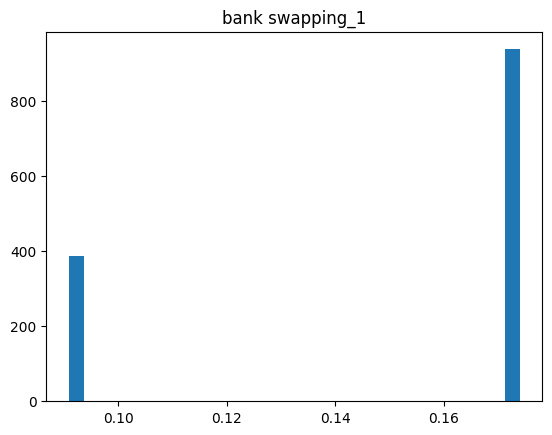

25


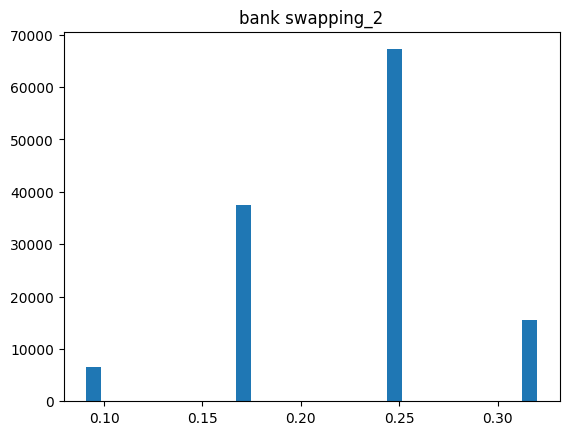

25


KeyboardInterrupt: 

In [ ]:
for dataset, df in all_datasets_results.items():
    for i, row in df.iterrows():
        if not row['method'].startswith('swapping'):
            continue
        # distribution = []
        # w_rset = row['w_rset']
        # for w in w_rset:
        #     distribution.extend(list(w.nonzero()[0]))

        # plt.title(f"{dataset} {row['method']}")
        # plt.hist(distribution, bins=30)
        # plt.show()

        iou_distribution = []
        w_rset = row['w_rset']
        print(w_rset.shape[1])
        for i in range(w_rset.shape[0]):
            for j in range(i + 1, w_rset.shape[0]):
                iou_distribution.append(inverse_IoU(w_rset[i], w_rset[j]))
        plt.title(f"{dataset} {row['method']}")
        plt.hist(iou_distribution, bins=30)
        plt.show()

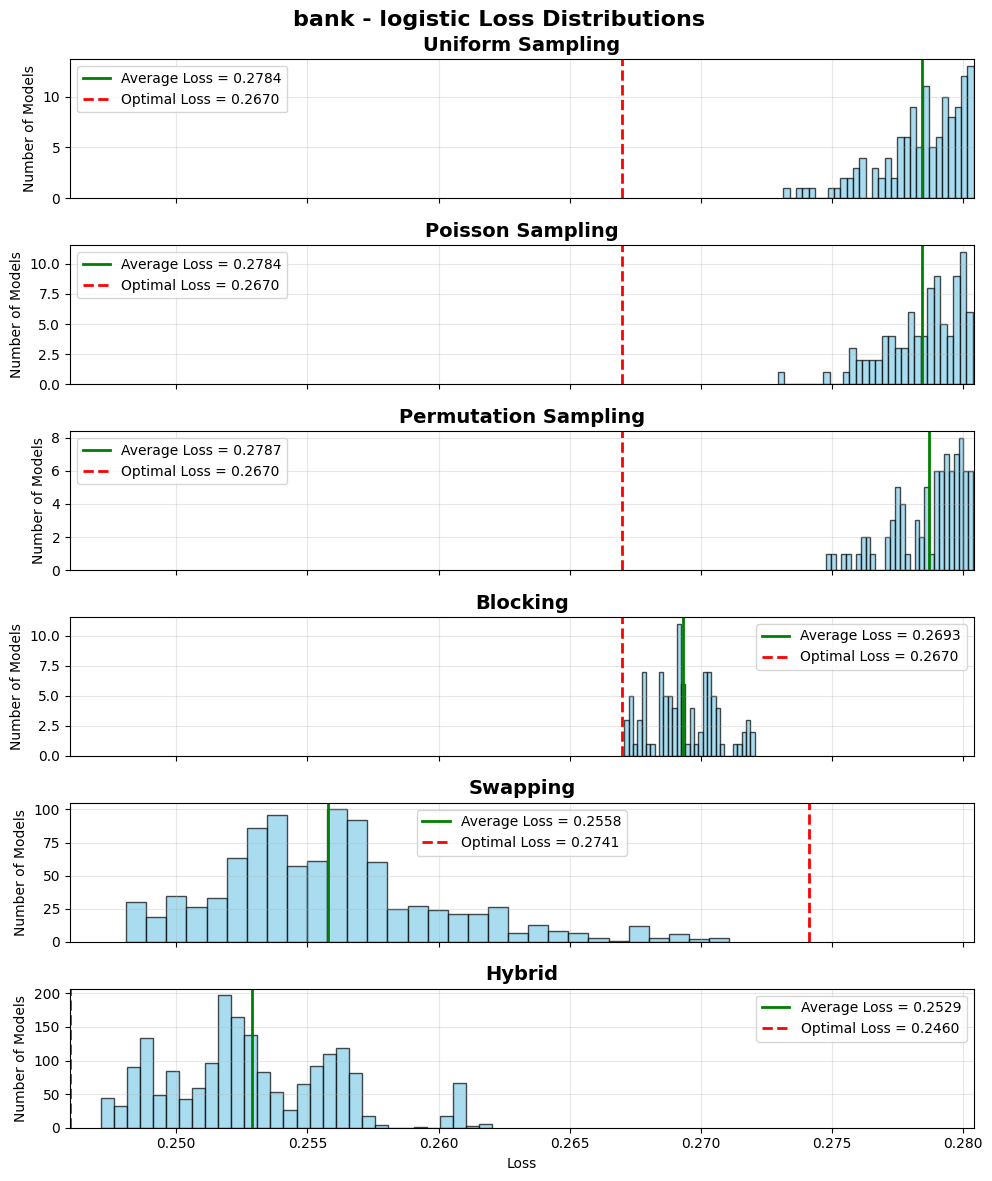

In [13]:
show_loss_distributions(all_datasets_results, "bank", "logistic")

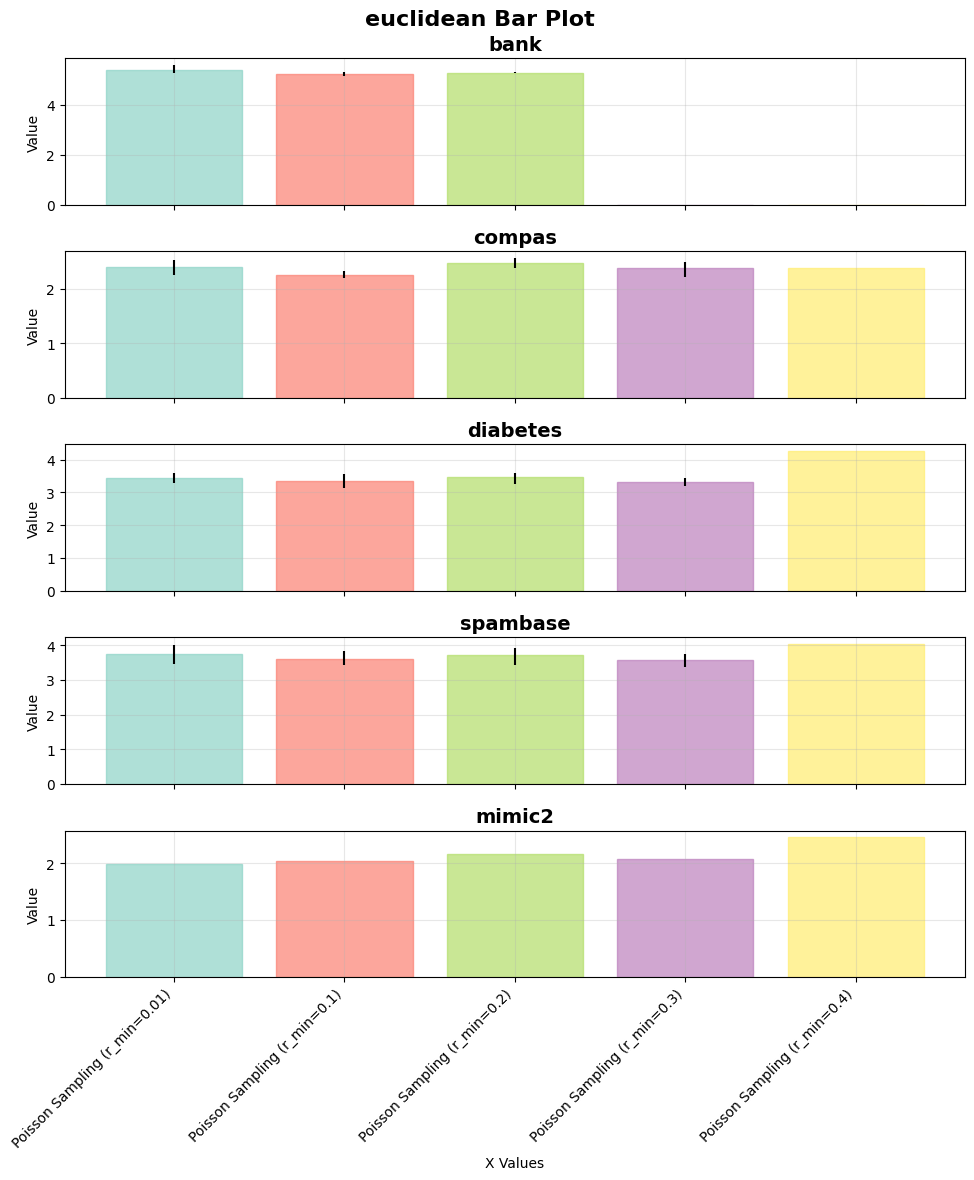

In [54]:
bar_metrics = ['accuracy', 'logistic', 'hamming', 'iou', 'euclidean', 'cosine', 'predictive_diversities']
bar_plot = get_bar_plot(all_datasets_results, 'euclidean', methods)

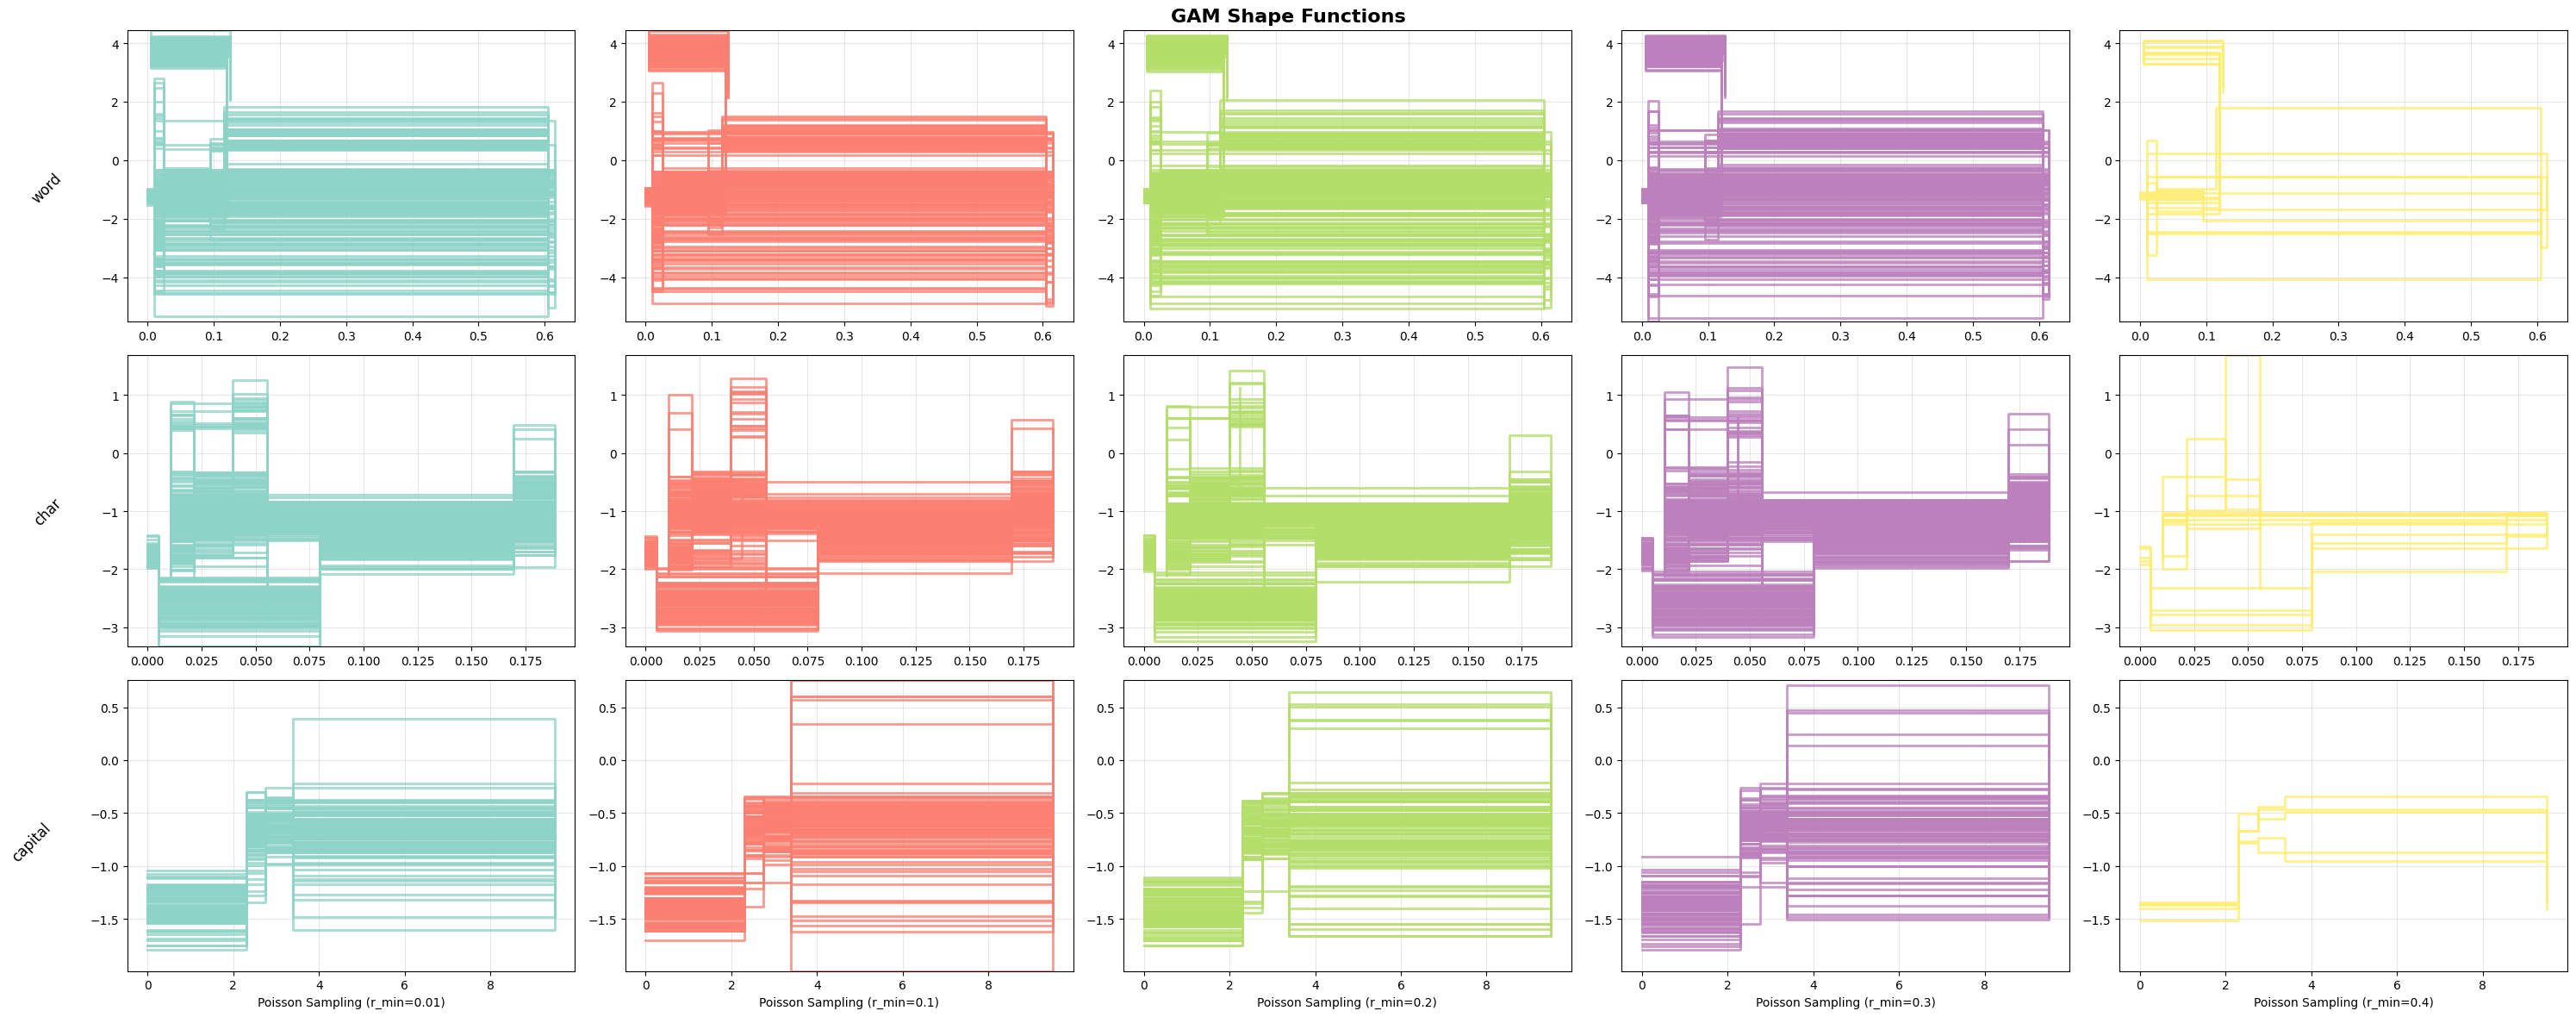

In [52]:
["bank", "compas", "diabetes", "spambase", "mimic2"]
gam = get_gam(all_datasets_results, 'spambase')

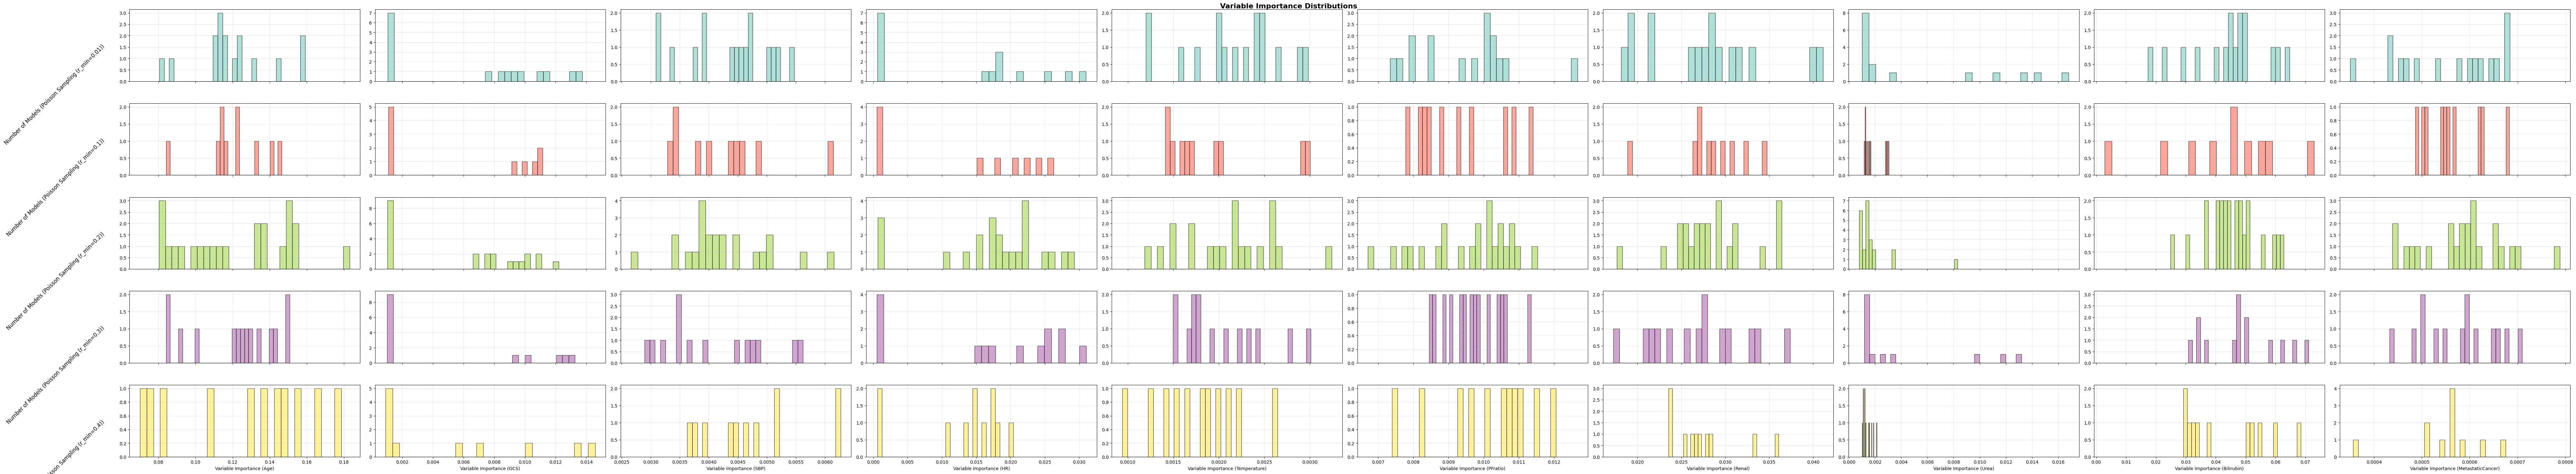

In [53]:
variable_importance = get_variable_importance(all_datasets_results, 'mimic2')

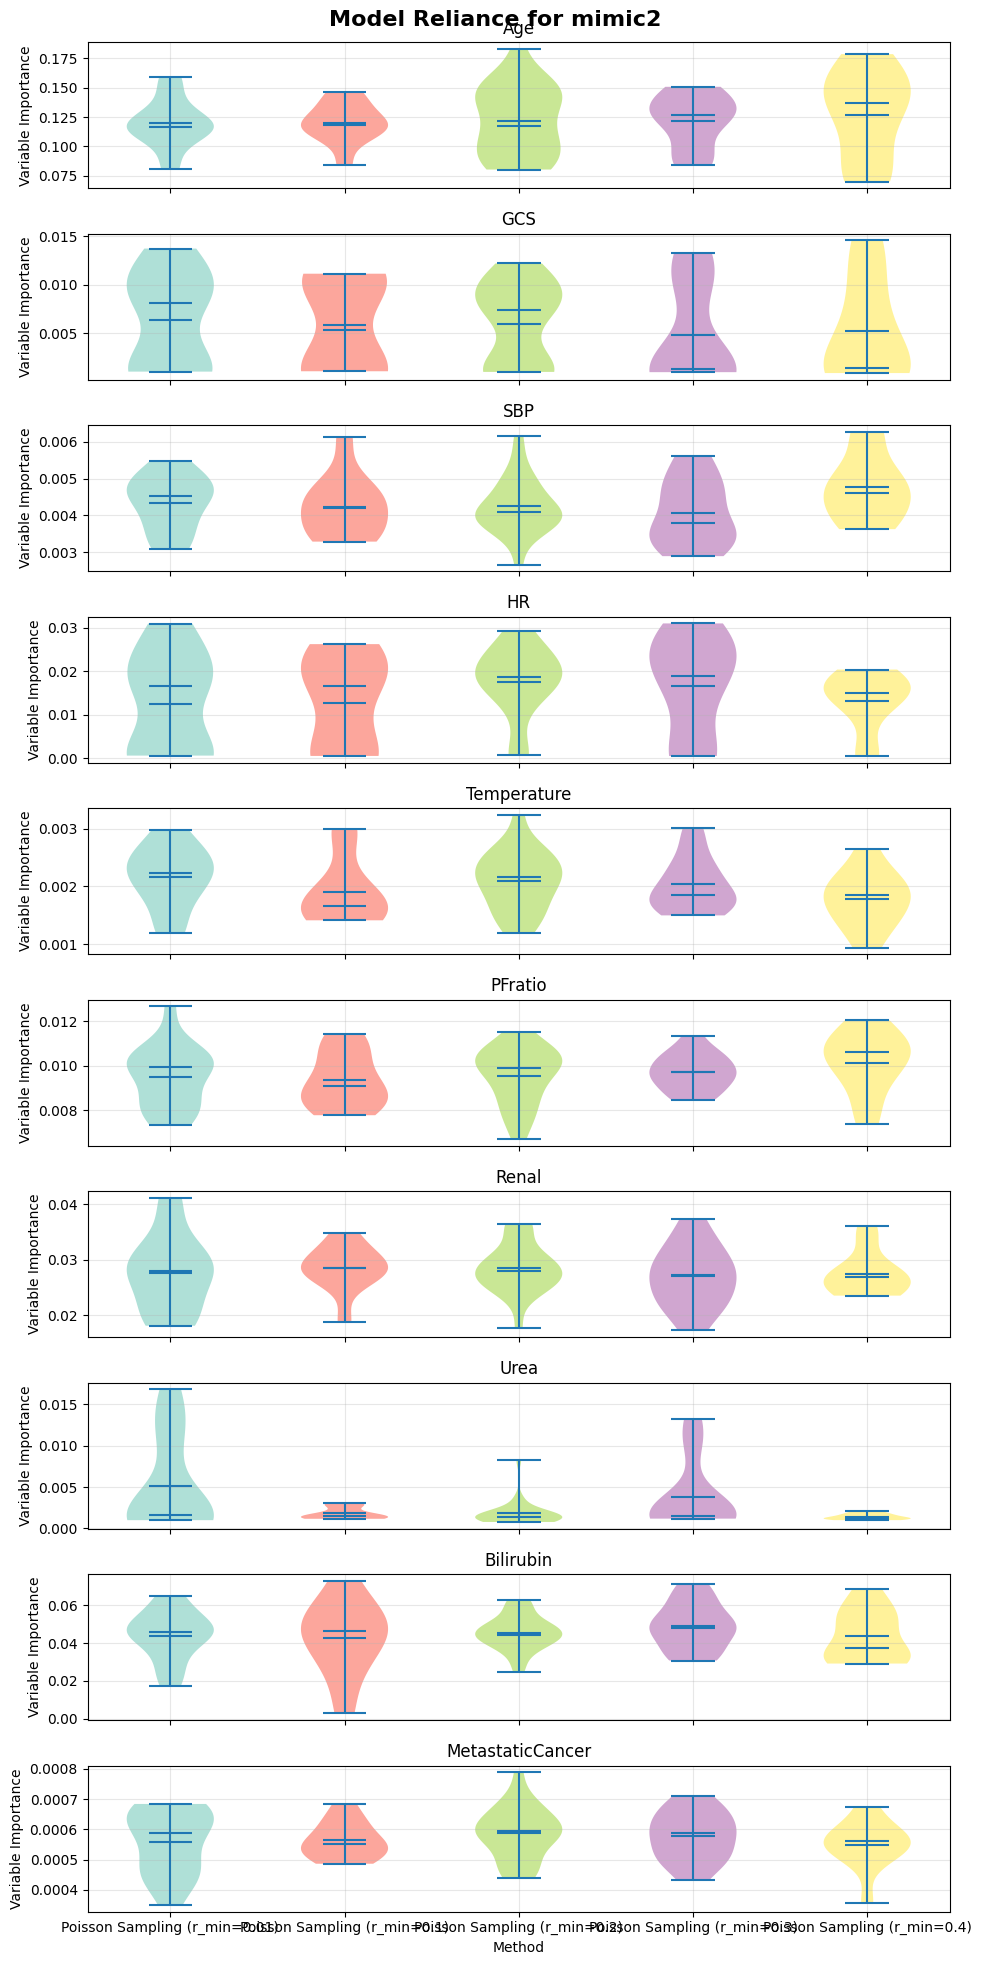

In [62]:
model_reliance = get_model_reliance(all_datasets_results, "mimic2")

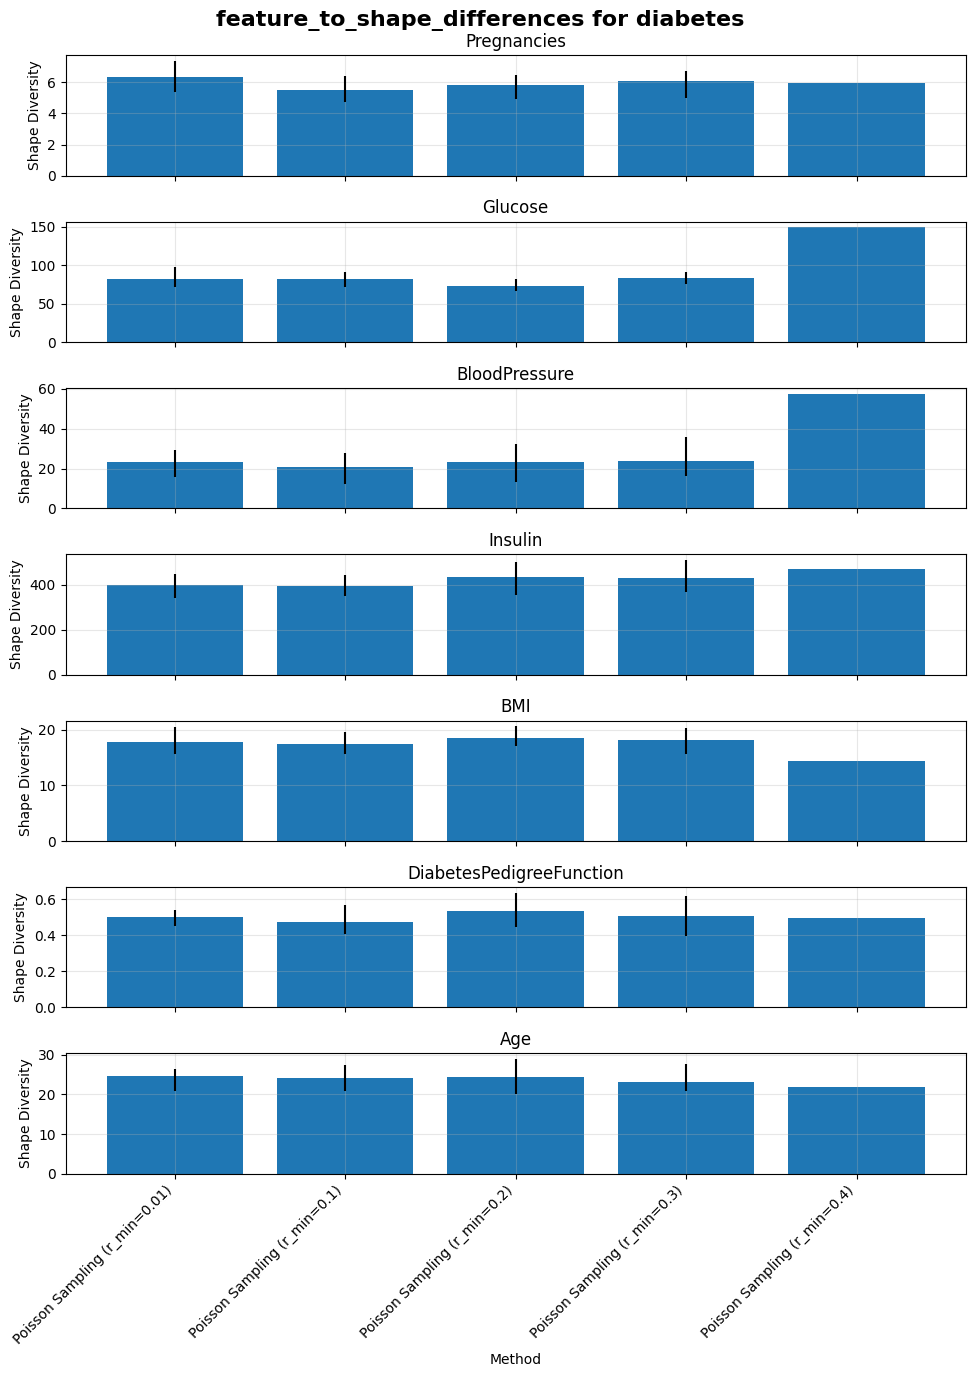

In [58]:
feature_to_shape_metrics = ['feature_to_shape_differences', 'feature_to_shape_diversities']
fsd = get_feature_to_shape_diversity(all_datasets_results, "diabetes", feature_to_shape_metrics[0])

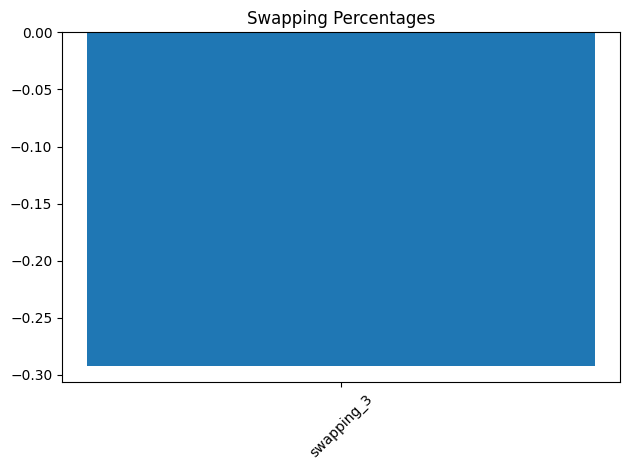

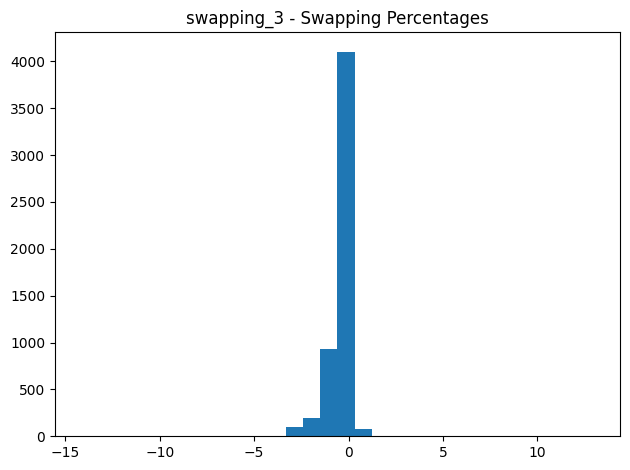

In [40]:
show_swapping_percentages(all_datasets_results, "bank")

In [ ]:
bar_metrics = ['iou', 'euclidean']
for bm in bar_metrics:
    fig = get_bar_plot(all_datasets_results, bm, methods)  # this should create/return the figure
    fig.savefig(f'figures/{bm}_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for dn in dataset_names:
    fig = get_gam(all_datasets_results, dn)
    fig.savefig(f'figures/{dn}_gam.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for dn in dataset_names:
    fig = get_variable_importance(all_datasets_results, dn)
    fig.savefig(f'figures/{dn}_variable_importance.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for dn in dataset_names:
    fig = get_model_reliance(all_datasets_results, dn)
    fig.savefig(f'figures/{dn}_model_reliance.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for fsd in feature_to_shape_metrics:
    fig = get_feature_to_shape_diversity(all_datasets_results, dn, fsd)
    fig.savefig(f'figures/{fsd}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)